# ESS 배터리 수명 예측 — DAY 1 EDA

- 데이터: MIT-Stanford Battery Dataset (Severson et al., Nature Energy 2019), LFP/흑연 18650 셀 (공칭 1.1Ah)
- 과제: **회귀** — 1\~100사이클 정보로 `cycle_life`(용량 0.88Ah = 80% 도달 사이클) 예측
- 원칙: ① 1\~100사이클 정보만 사용 ② 피처·기준값은 Batch 1만 보고 결정 ③ Batch 2, 3은 배치 차이 확인용

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from load_data import build_cache, load_cells, load_summary, load_qdlin, clean_summary, EOL_AH
import viz
viz.setup()
build_cache()            # .mat → data/processed 캐시 (처음 1회만 실제로 읽음)
cells = load_cells()
summary = clean_summary(load_summary())
pd.set_option('display.width', 160)

## 0. 데이터 진단 — 정답을 믿을 수 있는 셀만 쓴다

| 상태 | 기준 | 처리 |
|---|---|---|
| 정상 (OK) | 정답 있음, 100사이클 이상, 기록 끝 용량 ≤ 0.89Ah | 사용 |
| 수명 끝 전 실험 종료 (CENSORED) | 기록 끝 용량 > 0.89Ah → 0.88Ah에 도달하지 않음 | 학습·평가 제외, "최소 이만큼은 산다" 검증용 |
| 정답 없음 (NO_LABEL) | cycle_life 비어 있음 | 제외 |
| 순간 튐 (spike) | 1\~2개 사이클만 QD > 1.3Ah | 앞뒤 값으로 보간, 셀 유지 |

In [2]:
status_tbl = pd.crosstab(cells.batch.map(viz.BATCH_LABEL), cells.status, margins=True, margins_name='합계')
status_tbl

status,CENSORED,NO_LABEL,OK,합계
batch,,,,
Batch 1 (학습),10,0,36,46
Batch 2 (테스트),0,8,39,47
Batch 3 (추가 테스트),0,2,44,46
합계,10,10,119,139


In [3]:
cells[cells.status != 'OK'][['cell', 'policy', 'cycle_life', 'n_cycles', 'qd_end', 'status']]

,cell,policy,cycle_life,n_cycles,qd_end,status
0,b1_c00,3.6C(80%)-3.6C,1190.0,1189,1.026499,CENSORED
1,b1_c01,3.6C(80%)-3.6C,1179.0,1178,1.038700,CENSORED
2,b1_c02,3.6C(80%)-3.6C,1177.0,1176,1.043586,CENSORED
3,b1_c03,4C(80%)-4C,1226.0,1225,0.971356,CENSORED
4,b1_c04,4C(80%)-4C,1227.0,1226,1.021865,CENSORED
8,b1_c08,5.4C(40%)-3.6C,879.0,878,0.970365,CENSORED
10,b1_c10,5.4C(50%)-3C,906.0,905,0.962339,CENSORED
12,b1_c12,5.4C(50%)-3.6C,902.0,901,0.915049,CENSORED
13,b1_c13,5.4C(50%)-3.6C,897.0,896,0.925050,CENSORED
22,b1_c22,6C(30%)-3.6C,891.0,890,0.965279,CENSORED


findfont: Failed to find font weight bold for AppleGothic, now using 400.


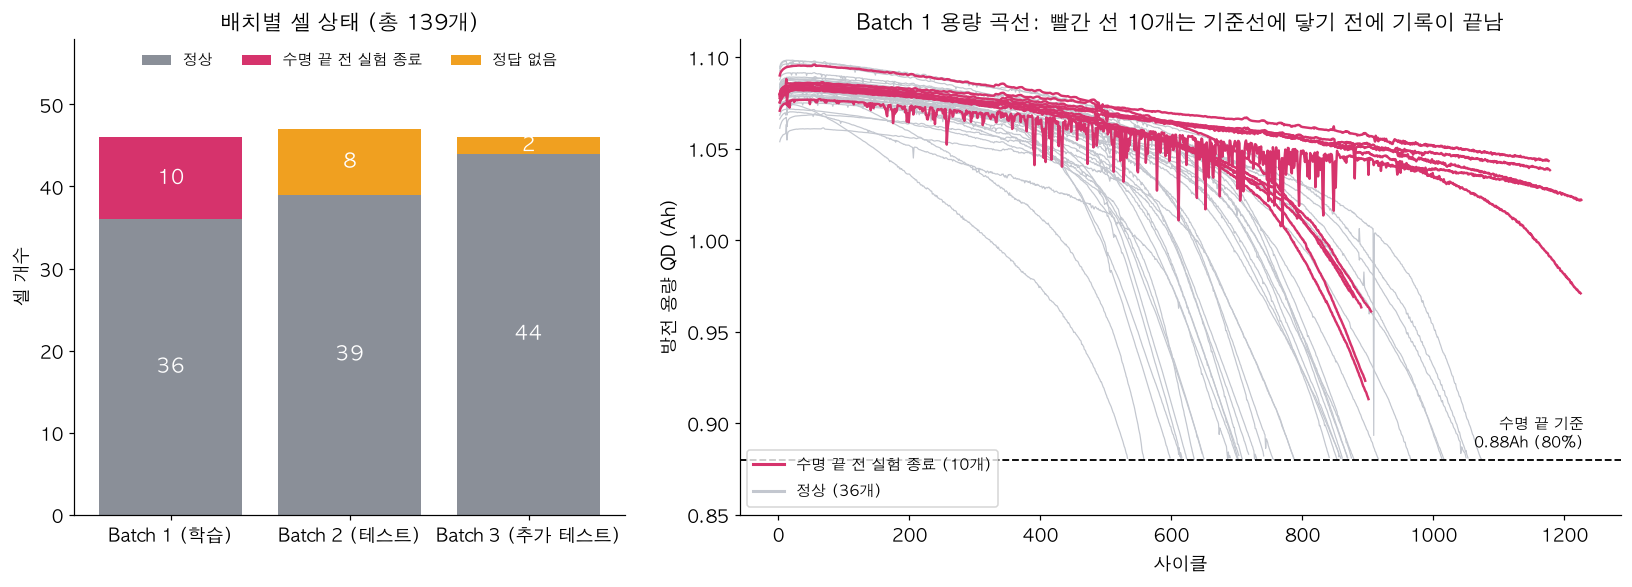

In [4]:
order = ['OK', 'CENSORED', 'NO_LABEL']
ct = pd.crosstab(cells.batch, cells.status).reindex(columns=order, fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={'width_ratios': [1, 1.6]})
bottom = np.zeros(len(ct))
for st in order:
    axes[0].bar([viz.BATCH_LABEL[b] for b in ct.index], ct[st], bottom=bottom,
                color=viz.STATUS_COLOR[st], label=viz.STATUS_LABEL[st])
    for i, (v, b0) in enumerate(zip(ct[st], bottom)):
        if v:
            axes[0].text(i, b0 + v / 2, str(v), ha='center', va='center', color='white', fontsize=13)
    bottom += ct[st].values
axes[0].set_title('배치별 셀 상태 (총 139개)')
axes[0].set_ylabel('셀 개수')
axes[0].set_ylim(0, 58)
axes[0].legend(loc='upper center', ncol=3, fontsize=9.5, frameon=False)

ax = axes[1]
b1 = cells[cells.batch == 'b1']
for _, r in b1.iterrows():
    d = summary[summary.cell == r.cell]
    cen = r.status == 'CENSORED'
    ax.plot(d.cycle, d.QD, color=viz.STATUS_COLOR['CENSORED'] if cen else '#c3c7cf',
            lw=1.6 if cen else 0.8, zorder=3 if cen else 1)
ax.axhline(EOL_AH, color='black', ls='--', lw=1.2)
ax.text(1230, EOL_AH + 0.004, '수명 끝 기준\n0.88Ah (80%)', fontsize=10, ha='right', va='bottom')
ax.plot([], [], color=viz.STATUS_COLOR['CENSORED'], lw=2, label='수명 끝 전 실험 종료 (10개)')
ax.plot([], [], color='#c3c7cf', lw=2, label='정상 (36개)')
ax.set_title('Batch 1 용량 곡선: 빨간 선 10개는 기준선에 닿기 전에 기록이 끝남')
ax.set_xlabel('사이클'); ax.set_ylabel('방전 용량 QD (Ah)')
ax.set_ylim(0.85, 1.11)
ax.legend(loc='lower left', fontsize=10)
fig.tight_layout()
viz.save(fig, 'q0_data_diagnosis')
plt.show()

In [5]:
b1_ok, b1_cen = b1[b1.status == 'OK'], b1[b1.status == 'CENSORED']
print(f"Batch 1 정상 셀 수명: 중앙값 {b1_ok.cycle_life.median():.0f}, 최대 {b1_ok.cycle_life.max():.0f}")
print(f"실험 종료 셀의 기록 길이: {b1_cen.n_cycles.min()} ~ {b1_cen.n_cycles.max()} (중앙값 {b1_cen.n_cycles.median():.0f})")
print(f"→ 실험 종료 셀 10개 모두 정상 셀 수명 중앙값보다 오래 버팀 = '장수명 셀'이 빠지는 효과")
print()
print("배치별 정상 셀 수명 요약")
cells[cells.status == 'OK'].groupby(cells.batch.map(viz.BATCH_LABEL)).cycle_life.describe().round(0)

Batch 1 정상 셀 수명: 중앙값 772, 최대 1074
실험 종료 셀의 기록 길이: 878 ~ 1226 (중앙값 1040)
→ 실험 종료 셀 10개 모두 정상 셀 수명 중앙값보다 오래 버팀 = '장수명 셀'이 빠지는 효과

배치별 정상 셀 수명 요약


,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
Batch 1 (학습),36.0,788.0,149.0,534.0,681.0,772.0,872.0,1074.0
Batch 2 (테스트),39.0,566.0,222.0,392.0,440.0,472.0,508.0,1186.0
Batch 3 (추가 테스트),44.0,1060.0,314.0,541.0,828.0,1006.0,1155.0,1935.0


**[목적]** 정답(cycle_life)을 믿을 수 있는 셀만 골라 학습·평가에 쓰기 위함

**[관찰]**
- Batch 1: 46개 중 **10개는 용량이 0.88Ah에 닿기 전에 실험이 끝남** → 기록된 cycle_life는 진짜 수명이 아니라 "실험이 멈춘 시점". 데이터 공개처 설명(실험 중단 후 다른 배치에서 재개, 일부 채널 조기 종료)과 일치
- 이 10개는 **모두 장수명 쪽**(878\~1,226사이클까지 멀쩡) → 빼면 Batch 1 수명 최대값이 1,227 → 1,074로 줄어듦
- Batch 2: 8개는 정답 없음 (VarCharge, SLOWCYCLE 등 다른 실험 방식 셀) → 남은 39개는 수명 중앙값 472로 Batch 1(773)보다 훨씬 짧음
- Batch 3: 2개 정답 없음, 수명 범위가 가장 넓음(541\~1,935)

**[시사점 → 모델]**
- 학습: Batch 1 정상 36개만 사용 (가짜 정답 차단)
- 단, 장수명 셀이 빠지므로 **모델이 긴 수명을 짧게 예측할 위험** → 실험 종료 셀 10개는 "예측값 ≥ 기록 길이인지" 확인하는 **최소 수명 검증**에 활용
- 배치마다 수명 범위가 크게 다름 → DAY 2 테스트에서 **Gap(Valid−Test) 발생 예상**, 원인을 미리 설명 가능

## ① Cycle Life 분포 — 배치마다 '시험 난이도'가 다르다

In [6]:
ok = cells[cells.status == 'OK'].copy()
ok['newstruct'] = ok.policy.str.contains('newstructure')
def group(r):
    if r.batch == 'b2':
        return 'Batch 2 (기존 방식)' if not r.newstruct else 'Batch 2 (newstructure)'
    return viz.BATCH_LABEL[r.batch].split(' (')[0]
ok['group'] = ok.apply(group, axis=1)

ratio = ok.groupby(ok.batch.map(viz.BATCH_LABEL)).cycle_life.agg(
    셀수='count', 중앙값='median', 최소='min', 최대='max',
    장수명비율=lambda x: (x > 1000).mean(), 단수명비율=lambda x: (x < 500).mean()).round(2)
ratio

,셀수,중앙값,최소,최대,장수명비율,단수명비율
batch,,,,,,
Batch 1 (학습),36,772.5,534.0,1074.0,0.14,0.00
Batch 2 (테스트),39,472.0,392.0,1186.0,0.08,0.72
Batch 3 (추가 테스트),44,1005.5,541.0,1935.0,0.52,0.00


In [7]:
# 이상치 셀 식별 (배치별 IQR 기준: Q1-1.5IQR 미만 / Q3+1.5IQR 초과)
rows = []
for b, g in ok.groupby('batch'):
    q1, q3 = g.cycle_life.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = g[g.cycle_life < q1 - 1.5 * iqr], g[g.cycle_life > q3 + 1.5 * iqr]
    rows.append({'배치': viz.BATCH_LABEL[b], '하한': round(q1 - 1.5 * iqr), '짧은 이상치': len(lo),
                 '상한': round(q3 + 1.5 * iqr), '긴 이상치': len(hi),
                 '긴 이상치 정책': ', '.join(sorted(set(hi.policy.str.replace('-newstructure', '*', regex=False))))})
display(pd.DataFrame(rows))
print('배치별 최단수명 3개 셀')
ok.sort_values('cycle_life').groupby('batch').head(3)[['batch', 'cell', 'policy', 'cycle_life']]

,배치,하한,짧은 이상치,상한,긴 이상치,긴 이상치 정책
0,Batch 1 (학습),395,0,1157,0,
1,Batch 2 (테스트),336,0,612,9,"4.8C(80%)-4.8C*, 5.2C(58%)-4C*, 5.6C(26%)-4.5C*"
2,Batch 3 (추가 테스트),337,0,1646,3,"4.8C(80%)-4.8C*, 5C(67%)-4C*"


배치별 최단수명 3개 셀


,batch,cell,policy,cycle_life
65,b2,b2_c19,6C(60%)-3C,392.0
52,b2,b2_c06,3.6C(9%)-5C,393.0
61,b2,b2_c15,3.6C(9%)-5C,396.0
20,b1,b1_c20,5.4C(80%)-5.4C,534.0
121,b3,b3_c28,3.7C(31%)-5.9C-newstructure,541.0
21,b1,b1_c21,5.4C(80%)-5.4C,559.0
45,b1,b1_c45,8C(35%)-3.6C,599.0
99,b3,b3_c06,3.7C(31%)-5.9C-newstructure,667.0
124,b3,b3_c31,5.9C(60%)-3.1C-newstructure,731.0


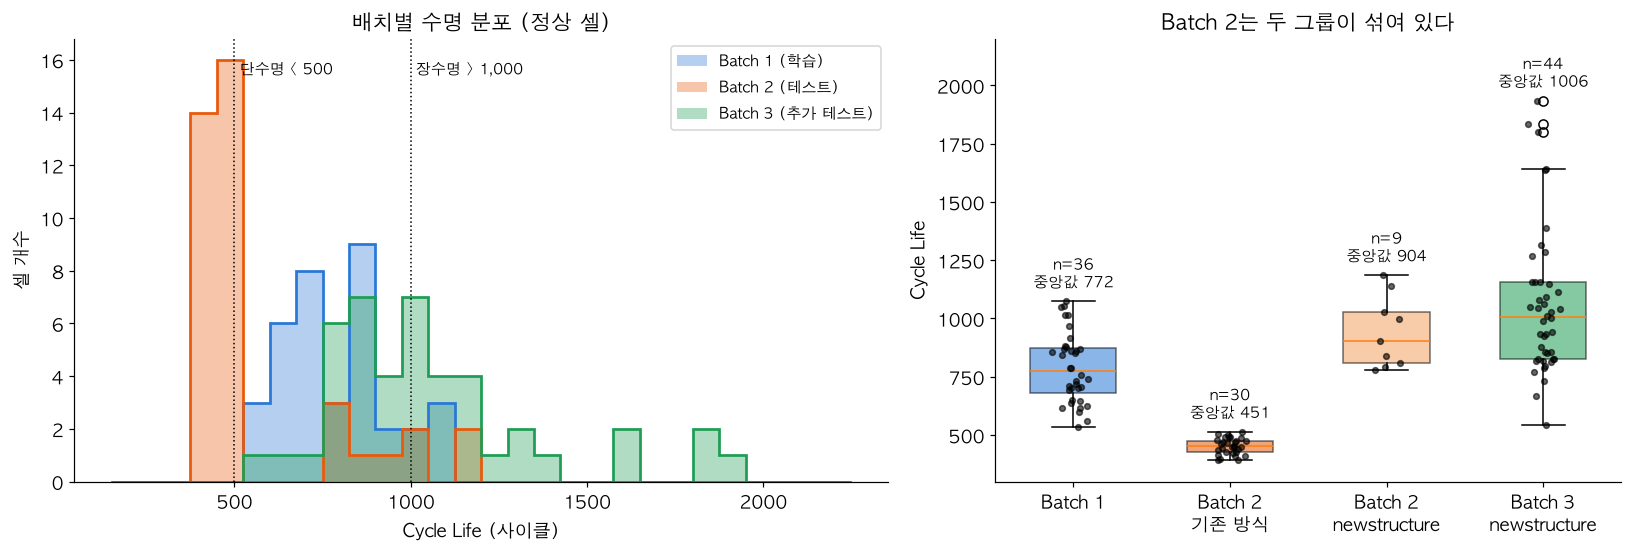

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={'width_ratios': [1.3, 1]})
bins = np.arange(150, 2325, 75)   # 과제 지정 범위 150~2,300
for b in ['b1', 'b2', 'b3']:
    axes[0].hist(ok[ok.batch == b].cycle_life, bins=bins, histtype='stepfilled', alpha=0.35,
                 color=viz.BATCH_COLOR[b], label=viz.BATCH_LABEL[b])
    axes[0].hist(ok[ok.batch == b].cycle_life, bins=bins, histtype='step', lw=1.8, color=viz.BATCH_COLOR[b])
for x, t in [(500, '단수명 < 500'), (1000, '장수명 > 1,000')]:
    axes[0].axvline(x, color='black', ls=':', lw=1)
    axes[0].text(x + 15, axes[0].get_ylim()[1] * 0.92, t, fontsize=10)
axes[0].set_title('배치별 수명 분포 (정상 셀)')
axes[0].set_xlabel('Cycle Life (사이클)'); axes[0].set_ylabel('셀 개수'); axes[0].legend(fontsize=10)

order = ['Batch 1', 'Batch 2 (기존 방식)', 'Batch 2 (newstructure)', 'Batch 3']
colors = [viz.BATCH_COLOR['b1'], viz.BATCH_COLOR['b2'], '#f4a261', viz.BATCH_COLOR['b3']]
data = [ok[ok.group == g].cycle_life for g in order]
bp = axes[1].boxplot(data, patch_artist=True, widths=0.55)
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col); patch.set_alpha(0.55)
for i, d in enumerate(data, 1):
    axes[1].scatter(np.random.normal(i, 0.05, len(d)), d, s=14, color='black', alpha=0.6, zorder=3)
    axes[1].text(i, d.max() + 60, f'n={len(d)}\n중앙값 {d.median():.0f}', ha='center', fontsize=9.5)
axes[1].set_xticks(range(1, 5), ['Batch 1', 'Batch 2\n기존 방식', 'Batch 2\nnewstructure', 'Batch 3\nnewstructure'])
axes[1].set_title('Batch 2는 두 그룹이 섞여 있다'); axes[1].set_ylabel('Cycle Life'); axes[1].set_ylim(300, 2200)
fig.tight_layout(); viz.save(fig, 'q1_distribution'); plt.show()

In [9]:
# 같은 충전 정책인데 배치가 다르면?
ok['base_policy'] = ok.policy.str.replace('-newstructure', '', regex=False)
same = ok.groupby(['base_policy', 'group']).cycle_life.mean().unstack()
same = same[same.notna().sum(axis=1) >= 2].round(0)
same

group,Batch 1,Batch 2 (newstructure),Batch 2 (기존 방식),Batch 3
base_policy,,,,
4.8C(80%)-4.8C,753.0,872.0,484.0,1564.0
5.2C(58%)-4C,NaN,962.0,478.0,NaN
5.6C(26%)-4.5C,NaN,991.0,448.0,NaN
6C(60%)-3C,744.0,NaN,400.0,NaN


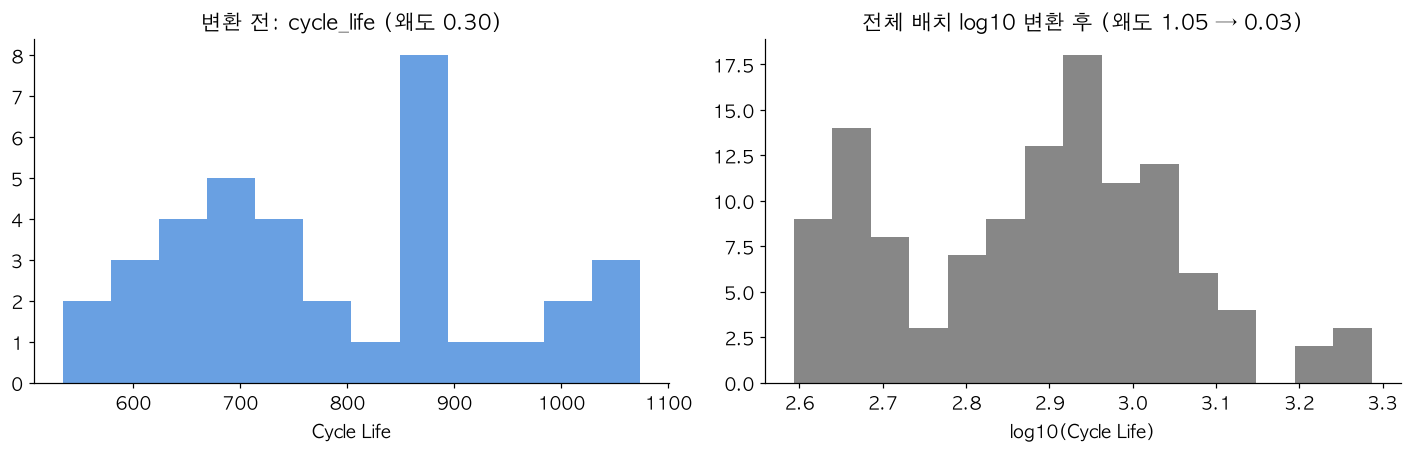

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
b1l = ok[ok.batch == 'b1'].cycle_life
axes[0].hist(b1l, bins=12, color=viz.BATCH_COLOR['b1'], alpha=0.7)
axes[0].set_title(f'변환 전: cycle_life (왜도 {b1l.skew():.2f})'); axes[0].set_xlabel('Cycle Life')
allok = ok.cycle_life
axes[1].hist(np.log10(allok), bins=15, color='#555', alpha=0.7)
axes[1].set_title(f'전체 배치 log10 변환 후 (왜도 {allok.skew():.2f} → {np.log10(allok).skew():.2f})')
axes[1].set_xlabel('log10(Cycle Life)')
fig.tight_layout(); viz.save(fig, 'q1_log_transform'); plt.show()

**[목적]** 맞혀야 할 정답(수명)이 배치마다 어떻게 생겼는지 확인 → 학습(Batch 1)과 시험(Batch 2, 3)이 같은 문제인지 판단

**[관찰]**
- 수명 범위: Batch 1 **534\~1,074**(단수명 0%, 장수명 14%) / Batch 2 **392\~1,186**(단수명 72%) / Batch 3 **541\~1,935**(장수명 52%)
- Batch 2는 **두 그룹이 섞여 있음**: 기존 방식 30개(중앙값 451) + newstructure 9개(중앙값 904). Batch 2의 '이상치'처럼 보이는 장수명 셀 9개는 전부 newstructure
- **같은 충전 정책인데 배치가 다르면 수명이 크게 다름**: 6C(60%)-3C → Batch 1 평균 744 vs Batch 2 400
- 이상치(IQR 기준): **짧은 쪽 이상치는 세 배치 모두 0개**. 긴 쪽 이상치는 Batch 2 9개(전부 newstructure), Batch 3 3개
- 상대적으로 짧은 셀: Batch 1 최단 3개는 5.4C(80%)-5.4C(534, 559), 8C(35%)-3.6C(599) — 처음부터 끝까지 또는 초반에 매우 빠르게 충전하는 정책 (④에서 검증)

**[시사점 → 모델]**
- 학습 범위(534\~1,074) 밖의 수명이 테스트에 많음 → **범위 밖 예측(외삽)이 필요** → 트리 모델은 학습 범위 밖을 예측하지 못하므로 **선형 계열 모델을 우선 후보**로
- 충전 정책만으로는 배치 차이를 설명할 수 없음 → **배치(생산·실험 조건)의 영향이 크다** = 현업의 '로트 변경 리스크'. DAY 2 Gap의 1순위 원인 후보
- 배치 간 수명 스케일 차이가 크고 평가가 상대오차(MAPE) → **타깃은 log 변환**하여 학습

## ② 열화 곡선 — 초반엔 멀쩡하다가, 수명의 약 70% 지점에서 꺾인다

In [11]:
from degradation import degradation_table
deg = degradation_table(ok, summary)
deg.groupby(deg.batch.map(viz.BATCH_LABEL))[['knee', 'knee_ratio', 'fade_early', 'fade_late']].median().round(3)

,knee,knee_ratio,fade_early,fade_late
batch,,,,
Batch 1 (학습),547.0,0.709,0.001,0.095
Batch 2 (테스트),339.0,0.736,-0.002,0.147
Batch 3 (추가 테스트),764.5,0.758,0.001,0.091


In [12]:
cap = summary[summary.cycle.isin([2, 100])].pivot(index='cell', columns='cycle', values='QD')
cap['chg_pct'] = (cap[100] / cap[2] - 1) * 100
cap = cap.join(ok.set_index('cell')[['batch']], how='inner')
print('2 → 100사이클 용량 변화율(%) 중앙값:')
print(cap.groupby(cap.batch.map(viz.BATCH_LABEL)).chg_pct.median().round(2))

2 → 100사이클 용량 변화율(%) 중앙값:
batch
Batch 1 (학습)        0.22
Batch 2 (테스트)       0.20
Batch 3 (추가 테스트)    0.13
Name: chg_pct, dtype: float64


findfont: Failed to find font weight bold for AppleGothic, now using 400.


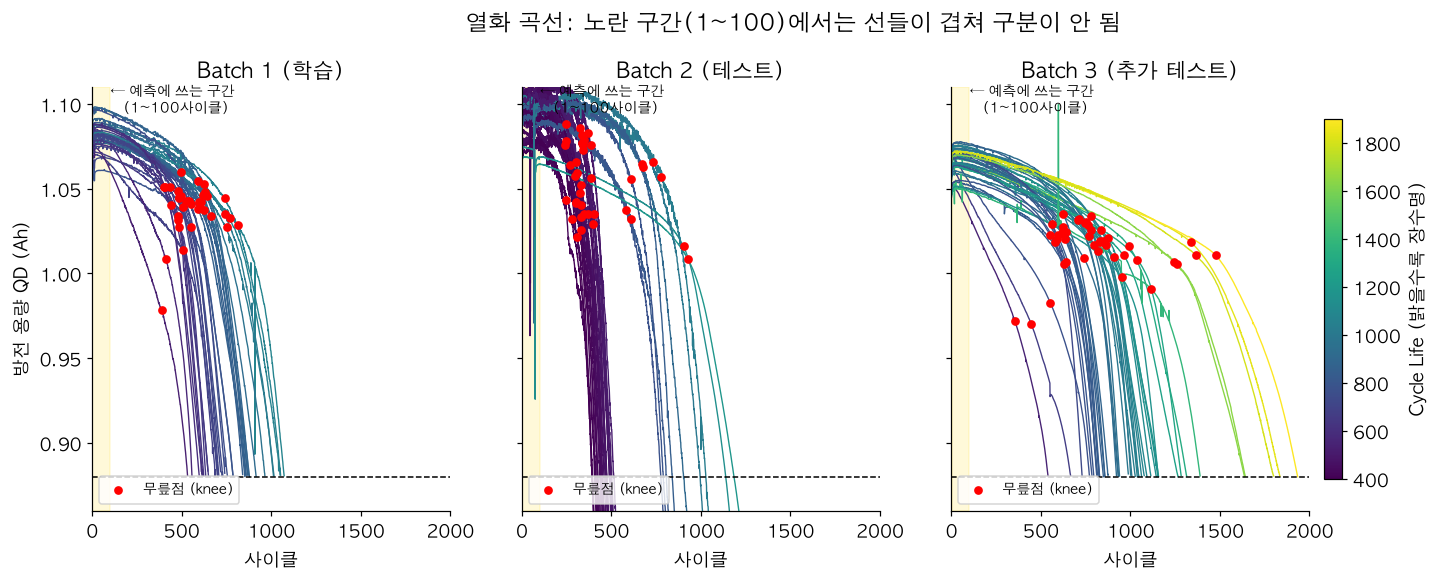

In [13]:
import matplotlib as mpl
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
norm = mpl.colors.Normalize(vmin=400, vmax=1900)
cmap = plt.cm.viridis
for ax, b in zip(axes, ['b1', 'b2', 'b3']):
    sub = ok[ok.batch == b]
    for _, r in sub.iterrows():
        d = summary[summary.cell == r.cell]
        ax.plot(d.cycle, d.QD, color=cmap(norm(r.cycle_life)), lw=0.9)
    kd = deg[deg.batch == b].merge(summary, left_on=['cell', 'knee'], right_on=['cell', 'cycle'])
    ax.scatter(kd.knee, kd.QD, s=22, color='red', zorder=3, label='무릎점 (knee)')
    ax.axvspan(1, 100, color='gold', alpha=0.15)
    ax.text(105, 1.095, '← 예측에 쓰는 구간\n   (1~100사이클)', fontsize=9)
    ax.axhline(EOL_AH, color='black', ls='--', lw=1)
    ax.set_title(viz.BATCH_LABEL[b]); ax.set_xlabel('사이클'); ax.set_xlim(0, 2000)
    ax.legend(loc='lower left', fontsize=9)
axes[0].set_ylabel('방전 용량 QD (Ah)'); axes[0].set_ylim(0.86, 1.11)
cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, shrink=0.85, pad=0.01)
cb.set_label('Cycle Life (밝을수록 장수명)')
fig.suptitle('열화 곡선: 노란 구간(1~100)에서는 선들이 겹쳐 구분이 안 됨', fontsize=15, fontweight='bold', y=1.02)
viz.save(fig, 'q2_degradation'); plt.show()

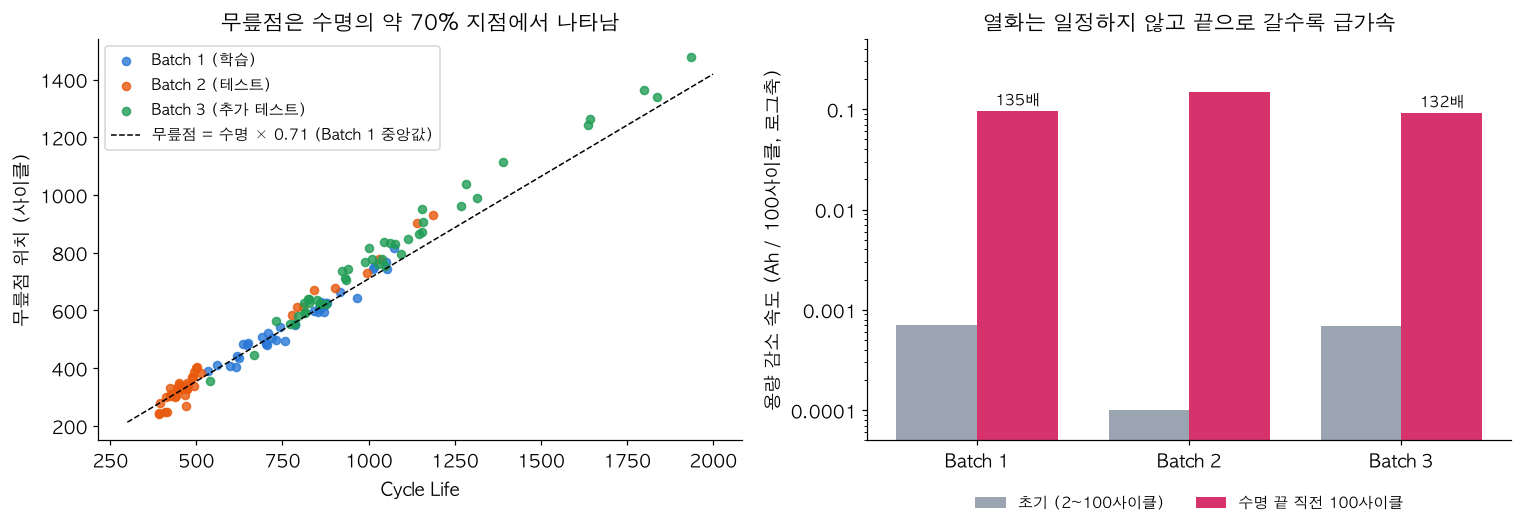

Batch 1 (학습): 무릎점/수명 0.65~0.76, corr(무릎점, 수명)=0.98, corr(초기 감소속도, 수명)=-0.51
Batch 2 (테스트): 무릎점/수명 0.57~0.80, corr(무릎점, 수명)=0.99, corr(초기 감소속도, 수명)=0.45
Batch 3 (추가 테스트): 무릎점/수명 0.66~0.82, corr(무릎점, 수명)=0.99, corr(초기 감소속도, 수명)=-0.34


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for b in ['b1', 'b2', 'b3']:
    g = deg[deg.batch == b]
    axes[0].scatter(g.cycle_life, g.knee, s=28, color=viz.BATCH_COLOR[b], label=viz.BATCH_LABEL[b], alpha=0.8)
xx = np.array([300, 2000])
r = deg[deg.batch == 'b1'].knee_ratio.median()
axes[0].plot(xx, r * xx, color='black', ls='--', lw=1, label=f'무릎점 = 수명 × {r:.2f} (Batch 1 중앙값)')
axes[0].set_xlabel('Cycle Life'); axes[0].set_ylabel('무릎점 위치 (사이클)')
axes[0].set_title('무릎점은 수명의 약 70% 지점에서 나타남'); axes[0].legend(fontsize=9.5)

med = deg.groupby('batch')[['fade_early', 'fade_late']].median()
x = np.arange(3); w = 0.38
axes[1].bar(x - w/2, med.fade_early.clip(lower=1e-4), w, label='초기 (2~100사이클)', color='#9aa5b1')
axes[1].bar(x + w/2, med.fade_late, w, label='수명 끝 직전 100사이클', color='#d6336c')
axes[1].set_yscale('log'); axes[1].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f'{v:g}')); axes[1].set_xticks(x, [viz.BATCH_LABEL[b].split(' (')[0] for b in med.index])
axes[1].set_ylabel('용량 감소 속도 (Ah / 100사이클, 로그축)')
axes[1].set_title('열화는 일정하지 않고 끝으로 갈수록 급가속'); axes[1].legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False); axes[1].set_ylim(5e-5, 0.5)
for i, (e, l) in enumerate(zip(med.fade_early.clip(lower=1e-4), med.fade_late)):
    axes[1].text(i + w/2, l * 1.15, f'{l/e:,.0f}배' if e > 2e-4 else '', ha='center', fontsize=10)
fig.tight_layout(); viz.save(fig, 'q2_knee'); plt.show()
for b, g in deg.groupby('batch'):
    print(f"{viz.BATCH_LABEL[b]}: 무릎점/수명 {g.knee_ratio.min():.2f}~{g.knee_ratio.max():.2f}, "
          f"corr(무릎점, 수명)={g.knee.corr(g.cycle_life):.2f}, corr(초기 감소속도, 수명)={g.fade_early.corr(g.cycle_life):.2f}")

**[목적]** 용량이 어떻게 줄어드는지 보고, **초반 용량만으로 수명을 맞힐 수 있는지** 판단

**[관찰]**
- 2 → 100사이클 용량 변화 중앙값: Batch 1 **+0.2%** (오히려 늘어남) → 논문 초록의 "초기 용량 대비 중앙값 0.2% 증가"와 일치. **100사이클 시점엔 모든 배터리가 멀쩡해 보임**
- 열화는 일정하지 않음: 수명 끝 직전 감소 속도가 초기보다 **약 100배 이상** 빠름 (가속형)
- **무릎점(급락 시작)은 수명의 65\~76% 지점** (Batch 1 중앙값 71%), 세 배치 모두 비슷 (71\~76%)
- 초기 감소 속도와 수명의 상관: Batch 1 −0.51, Batch 2 **+0.45** → 배치마다 방향이 뒤집힘 = 믿을 수 없는 신호

**[시사점 → 모델]**
- 1\~100사이클 **용량 값/감소 속도만으로는 예측 불가** → 곡선 '모양'의 미세한 변화(③ ΔQ)를 봐야 함
- 초기 용량 감소 속도는 배치마다 방향이 바뀌어 **단독 피처로 부적합** (보조 후보로만)
- 운영 가설: 이 데이터에서는 무릎점이 수명의 약 70% 부근에서 관찰됨 → 급락 감지를 교체 준비 신호로 쓸 수 있는지 현장 데이터로 검증 필요. 단, 무릎점은 '꺾인 뒤에야' 알 수 있음 → 꺾이기 전에 알려 주는 조기 예측 모델이 필요한 이유

## ③ ΔQ(V) 곡선 — 용량은 같아도 '곡선 모양'은 이미 다르다

- Qdlin: 방전 곡선을 전압 축(3.5V → 2.0V, 1,000개 점)으로 맞춘 누적 방전 용량
- **ΔQ(V) = Q₁₀₀(V) − Q₁₀(V)**: 같은 셀의 100번째와 10번째 방전 곡선 차이 → 같은 셀끼리 빼므로 배치별 측정 기준 차이가 상쇄됨

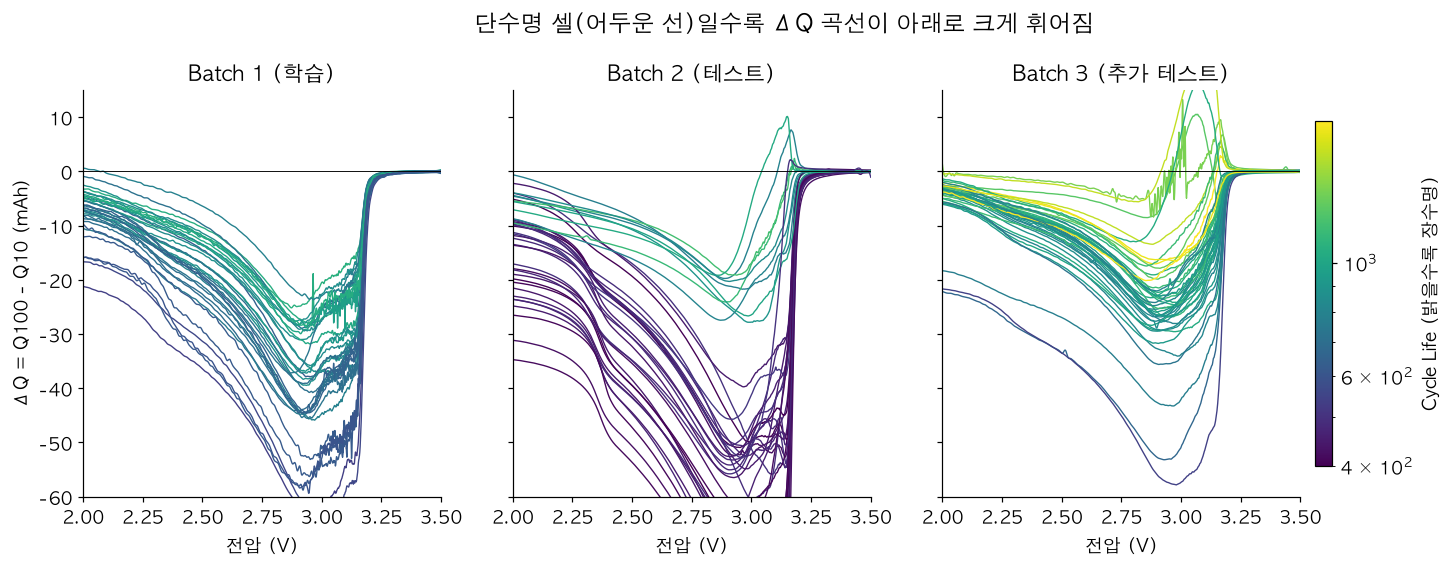

In [15]:
from features import build_features, FEATURE_GROUPS, dq_features
F = build_features(ok, summary)
F = F.merge(ok[['cell', 'group']], on='cell')

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
norm = mpl.colors.LogNorm(vmin=400, vmax=1900)
for ax, b in zip(axes, ['b1', 'b2', 'b3']):
    q, v, cyc, cid = load_qdlin(b)
    life = ok.set_index('cell').cycle_life
    for k, c_ in enumerate(cid):
        if c_ not in life.index:
            continue
        dq = q[k, cyc.index(100)] - q[k, cyc.index(10)]
        ax.plot(v, dq * 1000, color=plt.cm.viridis(norm(life[c_])), lw=0.9)
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlim(2.0, 3.5); ax.set_title(viz.BATCH_LABEL[b]); ax.set_xlabel('전압 (V)')
axes[0].set_ylabel('ΔQ = Q100 - Q10 (mAh)')
axes[0].set_ylim(-60, 15)
cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap='viridis'), ax=axes, shrink=0.85, pad=0.01)
cb.set_label('Cycle Life (밝을수록 장수명)')
fig.suptitle('단수명 셀(어두운 선)일수록 ΔQ 곡선이 아래로 크게 휘어짐', fontsize=15, fontweight='bold', y=1.03)
viz.save(fig, 'q3_dq_curves'); plt.show()

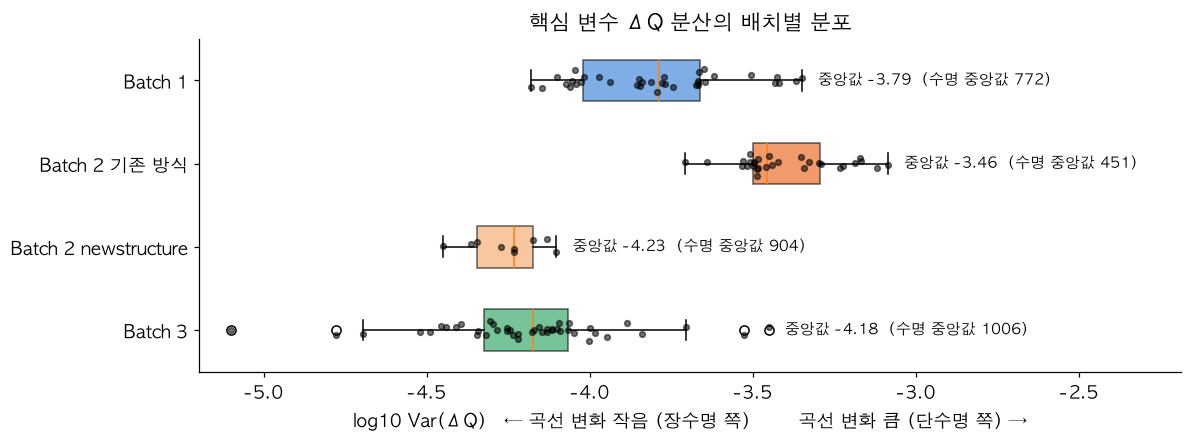

,count,25%,50%,75%
group,,,,
Batch 1,36.0,-4.02,-3.79,-3.66
Batch 2 (newstructure),9.0,-4.34,-4.23,-4.18
Batch 2 (기존 방식),30.0,-3.50,-3.46,-3.29
Batch 3,44.0,-4.32,-4.18,-4.07


In [16]:
# 핵심 변수(ΔQ log 분산)의 배치·그룹별 분포
groups = ['Batch 1', 'Batch 2 (기존 방식)', 'Batch 2 (newstructure)', 'Batch 3']
gcol = [viz.BATCH_COLOR['b1'], viz.BATCH_COLOR['b2'], '#f4a261', viz.BATCH_COLOR['b3']]
fig, ax = plt.subplots(figsize=(11, 4.2))
data = [F[F.group == g].dq100_logvar for g in groups]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, vert=False)
for patch, col in zip(bp['boxes'], gcol):
    patch.set_facecolor(col); patch.set_alpha(0.6)
for i, d in enumerate(data, 1):
    ax.scatter(d, np.random.normal(i, 0.06, len(d)), s=14, color='black', alpha=0.55, zorder=3)
    ax.text(d.max() + 0.05, i, f'중앙값 {d.median():.2f}  (수명 중앙값 {F[F.group == groups[i-1]].cycle_life.median():.0f})', va='center', fontsize=9.5)
ax.set_yticks(range(1, 5), ['Batch 1', 'Batch 2 기존 방식', 'Batch 2 newstructure', 'Batch 3'])
ax.set_xlabel('log10 Var(ΔQ)   ← 곡선 변화 작음 (장수명 쪽)        곡선 변화 큼 (단수명 쪽) →')
ax.set_xlim(F.dq100_logvar.min() - 0.1, F.dq100_logvar.max() + 0.9)
ax.invert_yaxis()
ax.set_title('핵심 변수 ΔQ 분산의 배치별 분포')
fig.tight_layout(); viz.save(fig, 'q3_dq_dist_by_batch'); plt.show()
F.groupby('group').dq100_logvar.describe()[['count', '25%', '50%', '75%']].round(2)

In [17]:
lab = FEATURE_GROUPS['lab']
corr_lab = pd.DataFrame({viz.BATCH_LABEL[b].split(' (')[0]: g[lab].corrwith(g.log_life) for b, g in F.groupby('batch')}).round(2)
corr_lab.index = ['log 분산', 'log |최소값|', 'log |평균|', '왜도', '첨도']
corr_lab

,Batch 1,Batch 2,Batch 3
log 분산,-0.84,-0.92,-0.76
log |최소값|,-0.82,-0.90,-0.74
log |평균|,-0.77,-0.87,-0.65
왜도,-0.43,-0.13,0.19
첨도,0.02,0.65,0.34


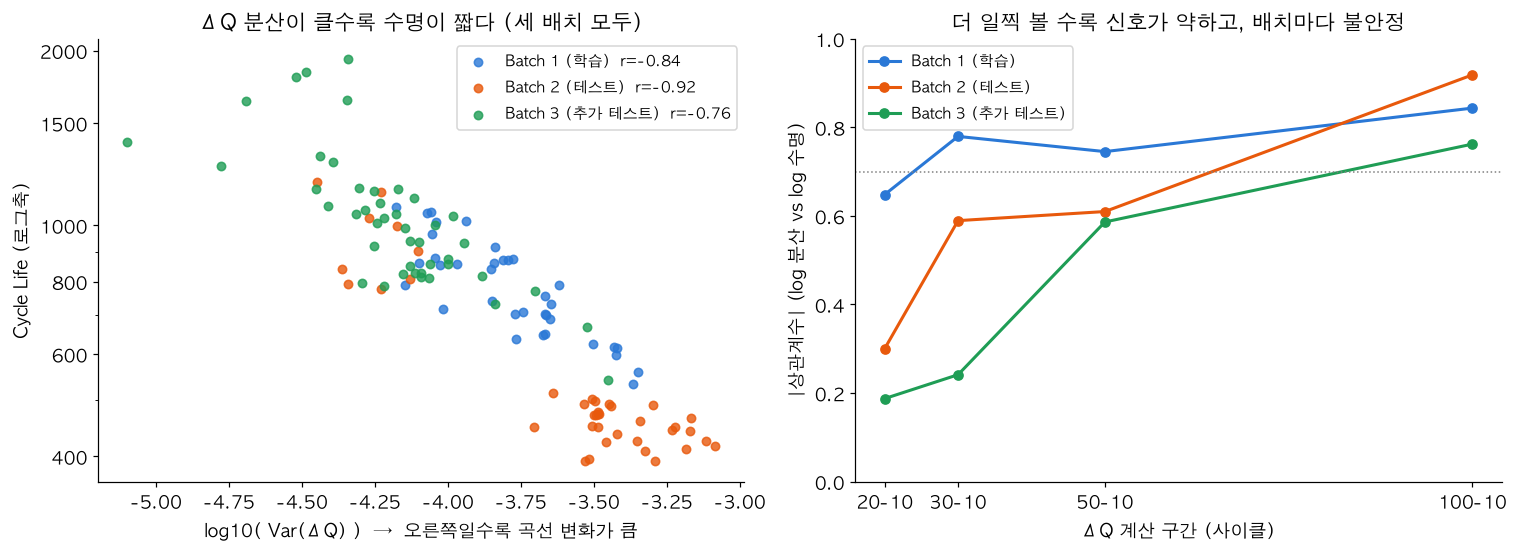

n,20,30,50,100
batch,,,,
b1,-0.65,-0.78,-0.75,-0.84
b2,-0.30,-0.59,-0.61,-0.92
b3,0.19,-0.24,-0.59,-0.76


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for b in ['b1', 'b2', 'b3']:
    g = F[F.batch == b]
    axes[0].scatter(g.dq100_logvar, g.cycle_life, s=30, alpha=0.8, color=viz.BATCH_COLOR[b],
                    label=f"{viz.BATCH_LABEL[b]}  r={g.dq100_logvar.corr(g.log_life):.2f}")
axes[0].set_yscale('log'); axes[0].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f'{v:g}'))
axes[0].set_yticks([400, 600, 800, 1000, 1500, 2000])
axes[0].set_xlabel('log10( Var(ΔQ) )  →  오른쪽일수록 곡선 변화가 큼')
axes[0].set_ylabel('Cycle Life (로그축)')
axes[0].set_title('ΔQ 분산이 클수록 수명이 짧다 (세 배치 모두)'); axes[0].legend(fontsize=10)

# 조기 예측: 몇 번째 사이클까지 보면 충분한가
early = []
for b in ['b1', 'b2', 'b3']:
    q, v, cyc, cid = load_qdlin(b)
    for n in [20, 30, 50, 100]:
        f = dq_features(q, cyc, a=n); f['cell'] = cid
        g = f.merge(F[F.batch == b][['cell', 'log_life']], on='cell')
        early.append({'batch': b, 'n': n, 'r': g[f'dq{n}_logvar'].corr(g.log_life)})
early = pd.DataFrame(early)
for b in ['b1', 'b2', 'b3']:
    e = early[early.batch == b]
    axes[1].plot(e.n, e.r.abs(), marker='o', lw=2, color=viz.BATCH_COLOR[b], label=viz.BATCH_LABEL[b])
axes[1].set_xticks([20, 30, 50, 100], ['20-10', '30-10', '50-10', '100-10'])
axes[1].set_xlabel('ΔQ 계산 구간 (사이클)'); axes[1].set_ylabel('|상관계수| (log 분산 vs log 수명)')
axes[1].set_ylim(0, 1); axes[1].axhline(0.7, color='gray', ls=':', lw=1)
axes[1].set_title('더 일찍 볼 수록 신호가 약하고, 배치마다 불안정'); axes[1].legend(fontsize=10)
fig.tight_layout(); viz.save(fig, 'q3_dq_feature'); plt.show()
early.pivot(index='batch', columns='n', values='r').round(2)

**[목적]** 용량 값으로는 구분이 안 되는 100사이클 시점에, 곡선 '모양'에는 수명 신호가 있는지 확인

**[관찰]**
- 단수명 셀일수록 ΔQ 곡선이 아래로 크게 휘어짐 (특히 2.9\~3.0V 부근 최저점) — 겉 용량은 같아도 **내부에서는 이미 변화가 진행 중**
- ΔQ **log 분산**과 log 수명의 상관: Batch 1 **−0.84**, Batch 2 **−0.92**, Batch 3 **−0.76** → 세 배치 모두에서 가장 강한 신호 (log 최소값도 비슷, 왜도·첨도는 약하고 불안정)
  - 단, Batch 2의 −0.92는 대부분 **두 그룹(기존/newstructure) 사이의 차이**에서 나옴. 기존 방식 30개만 보면 −0.38 (수명이 392\~514로 좁게 몰려 있어 구분할 폭 자체가 작음)
- 더 이른 구간: 50−10은 −0.75/−0.61/−0.59, 20−10은 −0.65/−0.30/+0.19 → **일찍 볼수록 신호가 약해지고 배치마다 흔들림**

**[시사점 → 모델]**
- **핵심 피처 = log10 Var(ΔQ₁₀₀₋₁₀)**, 보조 = log |최소값| (둘은 거의 같은 정보 → ⑤에서 다중공선성 처리)
- 같은 셀 안의 차이(ΔQ)를 쓰므로 노션 힌트의 '배치별 Qdlin 시작점 차이' 왜곡은 상당 부분 상쇄될 것으로 판단
- 관계가 log−log 직선에 가까움 → **선형 회귀로도 충분히 설명 가능**한 구조 (모델 선택 근거)
- 조기 예측(50사이클)은 '가능성'은 있으나 배치 간 안정성이 떨어짐 → **메인은 노션 정의대로 100사이클**, 50사이클은 고객 옵션(빠른 대신 덜 정확)으로 제시

## ④ 충전 조건과 수명 — '얼마나 빨리'보다 '얼마나 고르게'

충전 정책 `C1(Q1%)-C2`: 0→Q1%까지 C1 속도, Q1→80%까지 C2 속도 (예: 8C(35%)-3.6C)
- **평균 C-rate**(0→80%) = 0.8 / (Q1/C1 + (0.8−Q1)/C2) → 충전 시간을 대표
- **최대 C-rate** = max(C1, C2) → 충전 중 가장 세게 밀어붙이는 순간

In [19]:
print('배치별 0→80% 평균 C-rate 범위 (= 충전 시간 설계)')
print(F.groupby(F.batch.map(viz.BATCH_LABEL)).C_avg.agg(['min', 'max']).round(2))
b1f = F[F.batch == 'b1']
print()
print('Batch 1: 평균 C-rate 구간별 수명')
print(b1f.groupby(pd.cut(b1f.C_avg, [3.9, 4.4, 4.8, 5.5])).cycle_life.agg(['count', 'mean']).round(0))

배치별 0→80% 평균 C-rate 범위 (= 충전 시간 설계)
                   min   max
batch                       
Batch 1 (학습)      4.00  5.40
Batch 2 (테스트)     4.79  4.81
Batch 3 (추가 테스트)  4.79  4.81

Batch 1: 평균 C-rate 구간별 수명
            count   mean
C_avg                   
(3.9, 4.4]     14  879.0
(4.4, 4.8]     18  751.0
(4.8, 5.5]      4  643.0


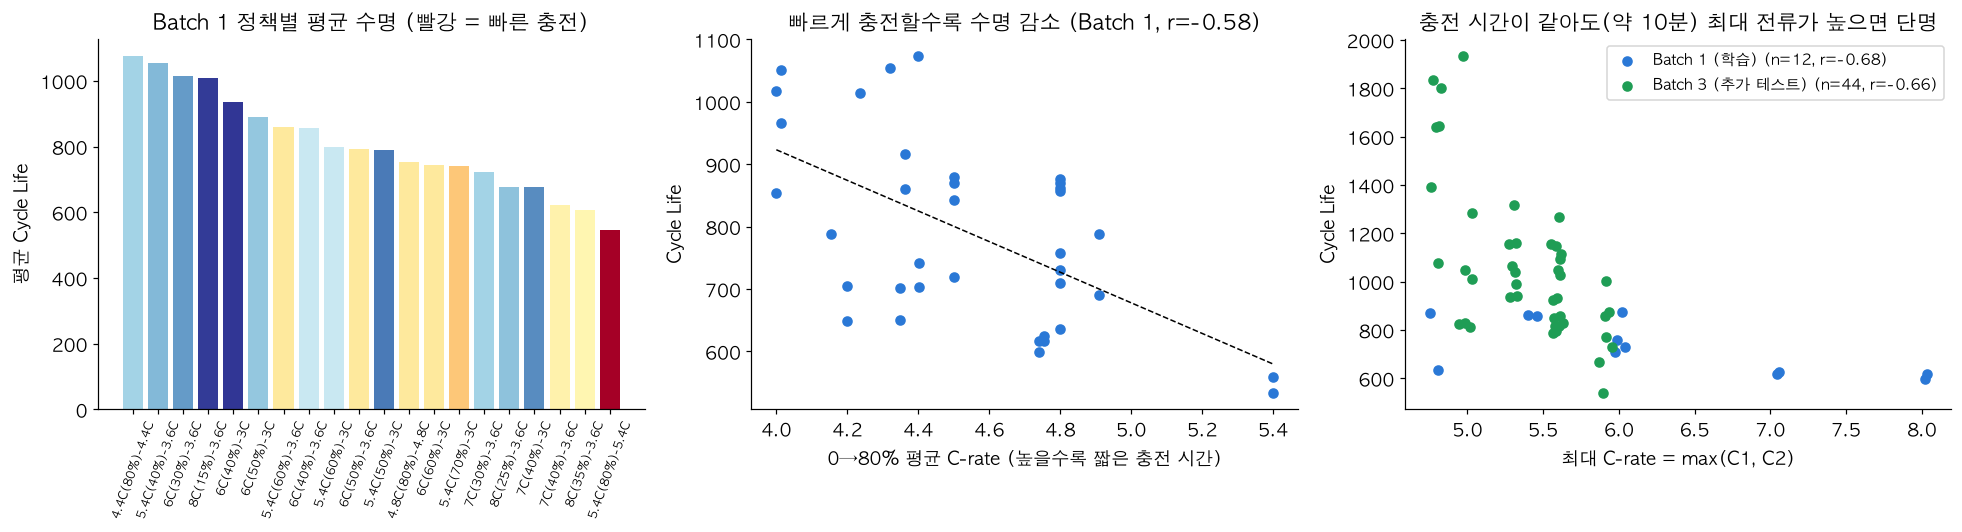

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pol = (b1f.groupby('policy').agg(life=('cycle_life', 'mean'), n=('cell', 'count'), C_avg=('C_avg', 'first'))
       .sort_values('life', ascending=False))
cols = plt.cm.RdYlBu_r((pol.C_avg - 4.0) / 1.4)
axes[0].bar(range(len(pol)), pol.life, color=cols)
axes[0].set_xticks(range(len(pol)), pol.index, rotation=70, fontsize=8)
axes[0].set_ylabel('평균 Cycle Life'); axes[0].set_title('Batch 1 정책별 평균 수명 (빨강 = 빠른 충전)')

axes[1].scatter(b1f.C_avg, b1f.cycle_life, s=35, color=viz.BATCH_COLOR['b1'])
m, c0 = np.polyfit(b1f.C_avg, b1f.cycle_life, 1)
xx = np.linspace(b1f.C_avg.min(), b1f.C_avg.max(), 10)
axes[1].plot(xx, m * xx + c0, color='black', ls='--', lw=1)
axes[1].set_xlabel('0→80% 평균 C-rate (높을수록 짧은 충전 시간)'); axes[1].set_ylabel('Cycle Life')
axes[1].set_title(f'빠르게 충전할수록 수명 감소 (Batch 1, r={b1f.C_avg.corr(b1f.cycle_life):.2f})')

same_t = pd.concat([b1f[(b1f.C_avg > 4.7) & (b1f.C_avg < 4.9)], F[F.batch == 'b3']])
for b in ['b1', 'b3']:
    g = same_t[same_t.batch == b]
    axes[2].scatter(g.C_max + np.random.normal(0, 0.03, len(g)), g.cycle_life, s=35, color=viz.BATCH_COLOR[b],
                    label=f"{viz.BATCH_LABEL[b]} (n={len(g)}, r={g.C_max.corr(g.cycle_life):.2f})")
axes[2].set_xlabel('최대 C-rate = max(C1, C2)'); axes[2].set_ylabel('Cycle Life')
axes[2].set_title('충전 시간이 같아도(약 10분) 최대 전류가 높으면 단명'); axes[2].legend(fontsize=9.5)
fig.tight_layout(); viz.save(fig, 'q4_charging'); plt.show()

In [21]:
# 충전 전류 패턴과 '열화 속도'의 상관 (과제 요구: 충전 전류 패턴과 열화 속도 상관 분석)
Fd = F.merge(deg[['cell', 'fade_early', 'fade_late']], on='cell')
rate = pd.DataFrame({viz.BATCH_LABEL[b].split(' (')[0]: {
    '평균 C-rate ↔ 초기 감소 속도(2~100)': g.C_avg.corr(g.fade_early),
    '평균 C-rate ↔ 말기 감소 속도(EOL 직전 100)': g.C_avg.corr(g.fade_late),
    '최대 C-rate ↔ 초기 감소 속도(2~100)': g.C_max.corr(g.fade_early),
    '최대 C-rate ↔ 말기 감소 속도(EOL 직전 100)': g.C_max.corr(g.fade_late)} for b, g in Fd.groupby('batch')}).round(2)
rate

,Batch 1,Batch 2,Batch 3
평균 C-rate ↔ 초기 감소 속도(2~100),0.62,0.33,-0.27
평균 C-rate ↔ 말기 감소 속도(EOL 직전 100),0.38,-0.20,0.27
최대 C-rate ↔ 초기 감소 속도(2~100),0.02,0.41,0.43
최대 C-rate ↔ 말기 감소 속도(EOL 직전 100),0.13,-0.06,0.22


In [22]:
print('Batch 3 (모두 0→80% 10분 충전) 정책별 평균 수명')
F[F.batch == 'b3'].groupby('policy').cycle_life.agg(['count', 'mean']).round(0).sort_values('mean')

Batch 3 (모두 0→80% 10분 충전) 정책별 평균 수명


,count,mean
policy,,
3.7C(31%)-5.9C-newstructure,3,660.0
5.9C(60%)-3.1C-newstructure,2,866.0
5.9C(15%)-4.6C-newstructure,2,867.0
5.6C(36%)-4.3C-newstructure,8,931.0
5.6C(19%)-4.6C-newstructure,8,1001.0
5.3C(54%)-4C-newstructure,8,1074.0
5C(67%)-4C-newstructure,7,1106.0
4.8C(80%)-4.8C-newstructure,6,1564.0


**[목적]** 고속충전이 정말 수명을 줄이는지, 충전 방식의 '어떤 요소'가 문제인지 확인 → 운영(충전 전략) 인사이트

**[관찰]**
- Batch 1 (충전 시간 8\~13분으로 다양): 평균 C-rate ≤4.4 → 평균 879, 4.4\~4.8 → 751, >4.8 → 643사이클 (r = −0.58). 단계별 속도(C1, C2) 하나만으로는 약함(r ≈ −0.24)
- **충전 시간이 같을 때(약 10분)**: 최대 C-rate가 높을수록 단명 — Batch 1 부분집합 r = −0.68, Batch 3 r = −0.66 (두 배치에서 같은 방향)
  - Batch 3 최장수 4.8C(80%)-4.8C(일정 속도) 평균 1,564 vs 최단수 3.7C(31%)-5.9C(후반에 몰아서) 660
- Batch 2·3은 충전 시간이 모두 같게(평균 4.8C) 설계됨 → 평균 C-rate로는 배치 내 차이를 설명할 수 없음
- **충전 패턴 ↔ 열화 속도**: Batch 1에서 평균 C-rate가 높을수록 초기 용량 감소가 빠름(r = 0.62), 말기 감소도 빠름(0.38). Batch 3에서는 최대 C-rate ↔ 초기 감소 속도 0.43. Batch 2는 방향이 일관되지 않음(그룹 혼재)

**[시사점 → 모델 & 운영]**
- 피처: **평균 C-rate**(충전 시간) + **최대 C-rate**(전류 쏠림)로 정책 문자열을 숫자화 — 정책당 셀이 2개뿐이라 정책 이름(원-핫)은 과적합 위험
- 단, 테스트 배치에서는 평균 C-rate가 사실상 상수 → 정책 피처의 기여는 제한적일 것으로 예상, ΔQ가 주력
- 운영 가설: 초고속충전(3.6C 이상) 실험 범위에서는 전류를 한 구간에 몰아 넣는 것과 짧은 수명이 연관됨. 저속으로 충방전하는 실제 ESS에도 해당하는지는 현장 검증 필요

## ⑤ 상관관계 — 배치가 바뀌어도 살아남는 신호는?

In [23]:
cand = FEATURE_GROUPS['lab'] + FEATURE_GROUPS['field'] + FEATURE_GROUPS['policy']
stab = pd.DataFrame({viz.BATCH_LABEL[b].split(' (')[0]: g[cand].corrwith(g.log_life) for b, g in F.groupby('batch')})
stab['그룹'] = ['실험실(ΔQ)'] * 5 + ['현장(BMS)'] * 11 + ['충전 정책'] * 5
stab['부호 일관'] = (np.sign(stab[['Batch 1', 'Batch 2', 'Batch 3']]).nunique(axis=1) == 1)
stab = stab.reindex(stab['Batch 1'].abs().sort_values(ascending=False).index)
stab.round(2)

,Batch 1,Batch 2,Batch 3,그룹,부호 일관
dq100_logvar,-0.84,-0.92,-0.76,실험실(ΔQ),True
dq100_logmin,-0.82,-0.90,-0.74,실험실(ΔQ),True
dq100_logmean,-0.77,-0.87,-0.65,실험실(ΔQ),True
C_avg,-0.59,0.35,-0.02,충전 정책,False
chargetime_5,0.57,-0.94,0.60,현장(BMS),False
fade_slope_2_100,0.55,-0.42,0.43,현장(BMS),False
qd_100_minus_2,0.52,-0.17,0.37,현장(BMS),False
fade_slope_91_100,0.44,0.27,0.38,현장(BMS),True
dq100_skew,-0.43,-0.13,0.19,실험실(ΔQ),False
ir_min,0.34,-0.57,0.17,현장(BMS),False


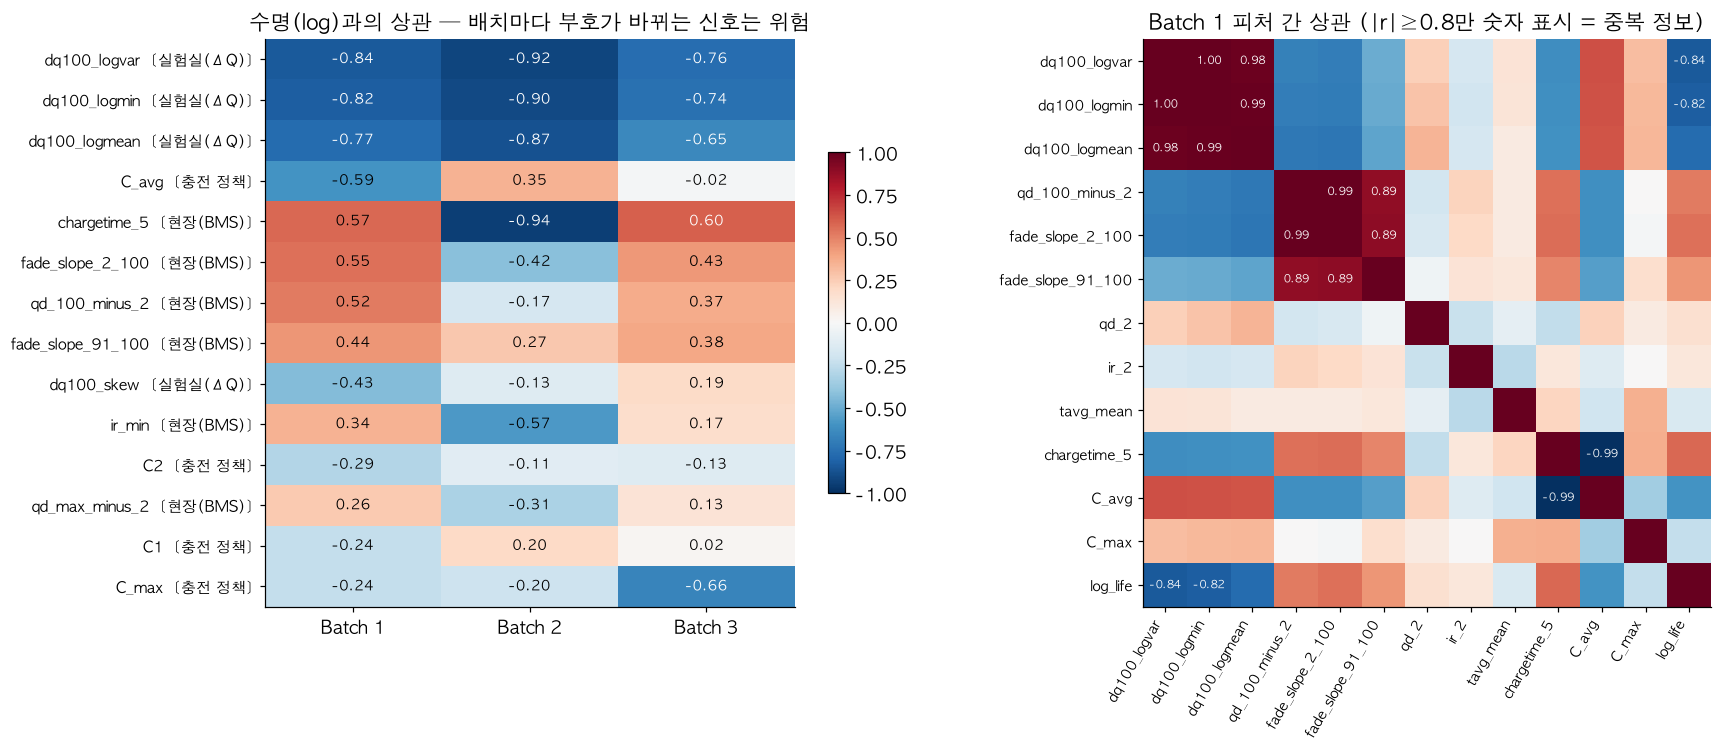

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={'width_ratios': [1, 1.25]})
show = stab.head(14)
im = axes[0].imshow(show[['Batch 1', 'Batch 2', 'Batch 3']].values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_yticks(range(len(show)), [f"{i}  [{g}]" for i, g in zip(show.index, show['그룹'])], fontsize=9.5)
axes[0].set_xticks(range(3), ['Batch 1', 'Batch 2', 'Batch 3'])
for i in range(len(show)):
    for j, col in enumerate(['Batch 1', 'Batch 2', 'Batch 3']):
        val = show[col].iloc[i]
        axes[0].text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                     color='white' if abs(val) > 0.6 else 'black')
axes[0].set_title('수명(log)과의 상관 — 배치마다 부호가 바뀌는 신호는 위험')
fig.colorbar(im, ax=axes[0], shrink=0.6)

sel = ['dq100_logvar', 'dq100_logmin', 'dq100_logmean', 'qd_100_minus_2', 'fade_slope_2_100',
       'fade_slope_91_100', 'qd_2', 'ir_2', 'tavg_mean', 'chargetime_5', 'C_avg', 'C_max']
cm = b1f[sel + ['log_life']].corr()
im2 = axes[1].imshow(cm.values, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(cm)), cm.columns, rotation=60, ha='right', fontsize=9)
axes[1].set_yticks(range(len(cm)), cm.columns, fontsize=9)
for i in range(len(cm)):
    for j in range(len(cm)):
        if abs(cm.values[i, j]) >= 0.8 and i != j:
            axes[1].text(j, i, f'{cm.values[i, j]:.2f}', ha='center', va='center', fontsize=7.5, color='white')
axes[1].set_title('Batch 1 피처 간 상관 (|r|≥0.8만 숫자 표시 = 중복 정보)')
fig.tight_layout(); viz.save(fig, 'q5_correlation'); plt.show()

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def vif(df):
    X = (df - df.mean()) / df.std()
    X = X.assign(const=1.0)
    return pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1] - 1)], index=df.columns).round(1)
print('VIF (10 이상 = 심한 다중공선성), Batch 1')
print(vif(b1f[['dq100_logvar', 'dq100_logmin', 'dq100_logmean', 'qd_100_minus_2', 'fade_slope_2_100', 'chargetime_5', 'C_avg']]))
print()
print('ΔQ 계열 1개만 남기면:')
print(vif(b1f[['dq100_logvar', 'qd_100_minus_2', 'chargetime_5', 'C_max']]))
pairs = [(a, b, round(cm.loc[a, b], 2)) for i, a in enumerate(sel) for b in sel[i + 1:] if abs(cm.loc[a, b]) >= 0.8]
print('\n|r| ≥ 0.8 피처 쌍:', pairs)

VIF (10 이상 = 심한 다중공선성), Batch 1
dq100_logvar        296.0
dq100_logmin        489.0
dq100_logmean        75.5
qd_100_minus_2      130.7
fade_slope_2_100    123.9
chargetime_5        220.9
C_avg               245.8
dtype: float64

ΔQ 계열 1개만 남기면:
dq100_logvar      4.6
qd_100_minus_2    2.0
chargetime_5      3.7
C_max             2.6
dtype: float64

|r| ≥ 0.8 피처 쌍: [('dq100_logvar', 'dq100_logmin', np.float64(1.0)), ('dq100_logvar', 'dq100_logmean', np.float64(0.98)), ('dq100_logmin', 'dq100_logmean', np.float64(0.99)), ('qd_100_minus_2', 'fade_slope_2_100', np.float64(0.99)), ('qd_100_minus_2', 'fade_slope_91_100', np.float64(0.89)), ('fade_slope_2_100', 'fade_slope_91_100', np.float64(0.89)), ('chargetime_5', 'C_avg', np.float64(-0.99))]


In [26]:
grp_best = stab.groupby('그룹')[['Batch 1', 'Batch 2', 'Batch 3']].agg(lambda x: x.abs().max()).round(2)
print('그룹별 최고 |상관| — 현장 측정 피처만으로도 될까?')
grp_best

그룹별 최고 |상관| — 현장 측정 피처만으로도 될까?


,Batch 1,Batch 2,Batch 3
그룹,,,
실험실(ΔQ),0.84,0.92,0.76
충전 정책,0.59,0.35,0.66
현장(BMS),0.57,0.94,0.60


**[목적]** 어떤 신호가 수명과 가장 강하게 연결되는지, 그리고 **배치가 바뀌어도 믿을 수 있는지** 확인

**[관찰]**
- 가장 강한 신호: **ΔQ log 분산** (−0.84 / −0.92 / −0.76) — 세 배치 모두 1\~2위, 부호 일관
- 현장(BMS) 피처는 배치마다 흔들림 (그룹별 최고 |상관|만 보면 Batch 2 현장 피처가 0.94로 높지만, 아래의 가짜 상관 때문):
  - 충전 시간(chargetime): Batch 1 **+0.57** vs Batch 2 **−0.94** → 부호가 뒤집힘. Batch 2 안에서 newstructure 그룹(충전 시간 약간 짧고 수명 2배)이 섞여 생긴 **가짜 상관**
  - 초기 용량 변화 기울기(fade_slope_2_100, 감소할수록 음수): Batch 1 +0.55, Batch 2 −0.42, Batch 3 +0.43 → 부호 반전 (②의 '초기 감소 속도'와 같은 현상, 부호 정의만 반대)
  - 평균 온도: 데이터 공개처가 "열전대 접촉이 불안정하다"고 명시 → 신뢰도 낮음
- 다중공선성: ΔQ log 분산·log 최소값·log 평균은 서로 |r| ≥ 0.9 (거의 같은 정보), 충전 시간 ↔ 평균 C-rate도 높음
- 내부저항(IR): Batch 2 일부 셀(6개)은 기록 없음 → 쓰려면 결측 처리 필요

**[시사점 → 모델]**
- 중심 피처는 **배치 간 부호가 일관된 ΔQ 계열**, 같은 정보 중 대표 1개(log 분산)만 사용하거나 **규제(ElasticNet)**로 중복을 눌러 줌
- 배치마다 부호가 뒤집히는 피처(충전 시간, 초기 기울기)는 **학습 데이터에서 좋아 보여도 테스트에서 오히려 해가 될 수 있음** → 후보에서 제외하거나 비교 실험으로만
- 💡 **현장 적용성**: 현장 피처만으로는 배치 간 안정적인 신호가 부족 → ΔQ를 얻으려면 실제 ESS에 **정기 진단 방전(일정 조건 완전 방전)** 절차가 필요

## 배치 비교 종합 — DAY 2 Gap을 미리 예상한다

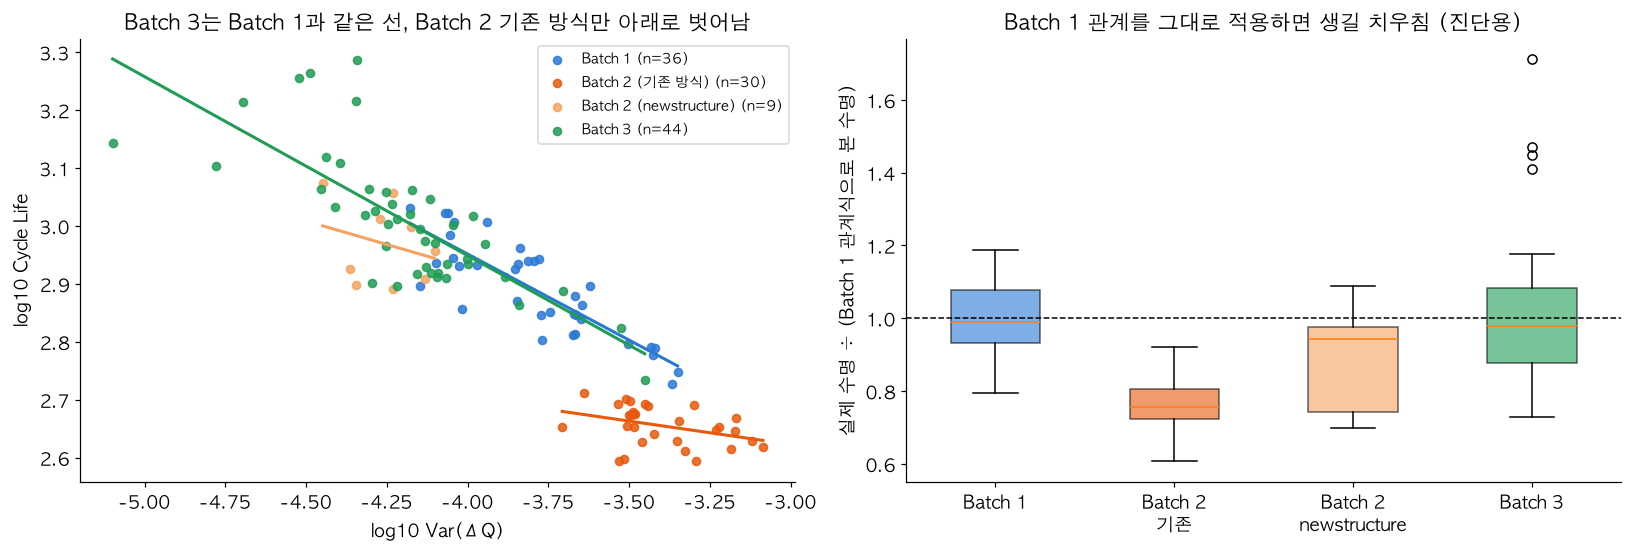

,그룹,기울기,절편,n
0,Batch 1,-0.297,1.762,36
1,Batch 2 (기존 방식),-0.081,2.381,30
2,Batch 2 (newstructure),-0.162,2.279,9
3,Batch 3,-0.309,1.712,44


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
groups = ['Batch 1', 'Batch 2 (기존 방식)', 'Batch 2 (newstructure)', 'Batch 3']
gcol = dict(zip(groups, [viz.BATCH_COLOR['b1'], viz.BATCH_COLOR['b2'], '#f4a261', viz.BATCH_COLOR['b3']]))
fits = []
for g in groups:
    d = F[F.group == g]
    axes[0].scatter(d.dq100_logvar, d.log_life, s=28, color=gcol[g], alpha=0.85, label=f'{g} (n={len(d)})')
    if len(d) >= 5:
        k, c0 = np.polyfit(d.dq100_logvar, d.log_life, 1)
        xx = np.linspace(d.dq100_logvar.min(), d.dq100_logvar.max(), 10)
        axes[0].plot(xx, k * xx + c0, color=gcol[g], lw=2)
        fits.append({'그룹': g, '기울기': round(k, 3), '절편': round(c0, 3), 'n': len(d)})
axes[0].set_xlabel('log10 Var(ΔQ)'); axes[0].set_ylabel('log10 Cycle Life')
axes[0].set_title('Batch 3는 Batch 1과 같은 선, Batch 2 기존 방식만 아래로 벗어남'); axes[0].legend(fontsize=9)

b1fit = np.polyfit(F[F.batch == 'b1'].dq100_logvar, F[F.batch == 'b1'].log_life, 1)
F['resid_b1line'] = F.log_life - np.polyval(b1fit, F.dq100_logvar)
data = [10 ** F[F.group == g].resid_b1line for g in groups]
bp = axes[1].boxplot(data, patch_artist=True, widths=0.5)
for patch, g in zip(bp['boxes'], groups):
    patch.set_facecolor(gcol[g]); patch.set_alpha(0.6)
axes[1].axhline(1, color='black', ls='--', lw=1)
axes[1].set_xticks(range(1, 5), ['Batch 1', 'Batch 2\n기존', 'Batch 2\nnewstructure', 'Batch 3'])
axes[1].set_ylabel('실제 수명 ÷ (Batch 1 관계식으로 본 수명)')
axes[1].set_title('Batch 1 관계를 그대로 적용하면 생길 치우침 (진단용)')
fig.tight_layout(); viz.save(fig, 'q6_batch_shift'); plt.show()
pd.DataFrame(fits)

In [28]:
# 그룹 내부 상관: Batch 2 상관(-0.92)이 그룹 간 차이에서 오는지 확인
F.groupby('group').apply(lambda g: pd.Series({'셀 수': len(g), 'corr(log Var ΔQ, log 수명)': round(g.dq100_logvar.corr(g.log_life), 2),
                                              '수명 범위': f"{g.cycle_life.min():.0f}~{g.cycle_life.max():.0f}"}))

,셀 수,"corr(log Var ΔQ, log 수명)",수명 범위
group,,,
Batch 1,36,-0.84,534~1074
Batch 2 (newstructure),9,-0.27,777~1186
Batch 2 (기존 방식),30,-0.38,392~514
Batch 3,44,-0.76,541~1935


In [29]:
bias = F.groupby('group').resid_b1line.median().pipe(lambda x: (10 ** x - 1) * 100).round(1)
print('Batch 1 관계식 대비 실제 수명 치우침 (중앙값, %):'); print(bias)

Batch 1 관계식 대비 실제 수명 치우침 (중앙값, %):
group
Batch 1                   -1.0
Batch 2 (newstructure)    -5.7
Batch 2 (기존 방식)          -24.3
Batch 3                   -2.1
Name: resid_b1line, dtype: float64


**[목적]** 학습(Batch 1)에서 찾은 관계가 다른 배치에도 그대로 통하는지 미리 점검 → DAY 2 Gap 원인을 사전에 설명

**[관찰]**
- **Batch 3는 Batch 1과 같은 관계를 따름**: 기울기 −0.31 vs −0.30, Batch 1 관계식 대비 치우침 −2% → 일반화 기대
- **Batch 2 기존 방식(30개)이 예외**: Batch 1 관계식으로 본 수명보다 실제 수명이 **약 24% 짧음**, 그룹 내 기울기도 거의 평평(−0.08)
- Batch 2 newstructure(9개)는 치우침 −6%로 Batch 1·3에 가까움
- 노션 힌트(배치별 분포 차이, 이상치 제거 고려)와 일치

**[시사점 → DAY 2 전략]**
- 예상: Batch 1으로 학습한 모델은 **Batch 2 기존 방식 셀의 수명을 길게(과대) 예측** → Test(Batch 2) MAPE가 Valid보다 크게 나올 가능성. 노션 예상과 달리 **Batch 3보다 Batch 2가 더 어려운 시험**일 수 있음
- 과대예측 = 현장에서는 '교체 시점을 놓치는' 위험한 방향 → 오류 분석에서 방향까지 보고
- Gap 해석은 **그룹별(기존/newstructure)로 나눠** 제시 — "모델이 나빠서"인지 "시험 조건이 달라서"인지 구분
- 대응 후보: ① 배치 간 안정적인 피처(ΔQ) 위주 단순 모델 ② 새 배치의 소수 셀로 절편만 재보정(현업의 '로트 보정') — 테스트 정보를 쓰므로 공식 성능표와 분리해 '운영 시나리오'로만 제시
- 현업 메시지: **새 생산 로트가 들어오면 소수 샘플로 모델을 점검·재보정하는 절차가 필수**